# Day 1: Linear Regression from Scratch

**Goal:** Implement the mathematical foundation of linear regression using only NumPy, before applying it to real data.

In [14]:
import numpy as np 
import matplotlib.pyplot as plt

## The Linear Hypothesis

Linear regression models the relationship between input features and a continuous target by computing a weighted sum of inputs plus a bias term:

$$\hat{y} = Xw + b$$

Where:
- $X$ is the input matrix of shape $(N, F)$ — $N$ samples, $F$ features
- $w$ is the weight vector of shape $(F,)$
- $b$ is a scalar bias
- $\hat{y}$ is the predicted output of shape $(N,)$

Each prediction is a linear combination of the features. The model learns $w$ and $b$ such that $\hat{y}$ is as close to the true target $y$ as possible.

Weights control the angle of the line — how steeply each feature pulls the prediction up or down. But without $b$, every possible line is forced through the origin. The bias shifts the entire line up or down freely, so the model can fit data that does not pass through zero.

In [15]:
def predict(X: np.ndarray, weights: np.ndarray, bias: float) -> np.ndarray:
    return X @ weights + bias

## Mean Squared Error Loss

To measure how far our predictions are from the true values, we use Mean Squared Error:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

We square the errors for two reasons.

First, without squaring, errors like $+5$ and $-5$ would cancel out in the sum, giving a loss of zero even though the model is badly wrong. Squaring makes every error positive so they all contribute.

Second, squaring penalizes large errors disproportionately. A prediction off by $10$ contributes $100$ to the loss, while one off by $1$ contributes only $1$. The model is pushed harder to fix its worst mistakes.

In [16]:
def mse_loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    return np.mean((y_pred - y_true) ** 2)

## Gradient Descent Optimization

To minimize MSE, we need to know how the loss changes as we nudge each parameter. That is the gradient — and we compute it by differentiating MSE with respect to $w$ and $b$.

### Derivative with respect to $w$

Start from the MSE definition:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Apply the chain rule — outer derivative first, then inner:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} 2(\hat{y}_i - y_i) \cdot \frac{\partial \hat{y}_i}{\partial w}$$

Since $\hat{y} = Xw + b$, the derivative of $\hat{y}_i$ with respect to $w_j$ is just $x_{ij}$ — the feature value for that sample:

$$\frac{\partial \hat{y}_i}{\partial w_j} = x_{ij}$$

So for each weight $w_j$, the sum plays out as:

$$\frac{\partial \text{MSE}}{\partial w_j} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot x_{ij}$$

We need this for every $w_j$ from $1$ to $F$. Writing all $F$ gradients at once in matrix form:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{N} X^T (\hat{y} - y)$$

### Why is $X$ transposed?

During the forward pass, $X$ is shape $(N, F)$ and $w$ is shape $(F,)$, giving us $N$ predictions:

$$(N, F) \cdot (F,) = (N,)$$

But in the backward pass we have $N$ errors and we want $F$ gradient updates — one per weight:

$$(F, N) \cdot (N,) = (F,)$$

Transposing $X$ from $(N, F)$ to $(F, N)$ gives us exactly that. Each row of $X^T$ is one feature across all samples, and dotting it with the error vector gives the total error signal for that weight. The sum did not disappear — it became the matrix multiplication.

### What does each gradient actually mean?

The gradient for $w_j$ is the mean error across all samples, weighted by how much $w_j$ contributed to each prediction. If a sample's feature $x_{ij}$ was large, that weight was heavily responsible for that prediction — so its error counts more. If the feature was near zero, that weight barely did anything, so its gradient is near zero too.

### Derivative with respect to $b$

Same chain rule, but since $\hat{y} = Xw + b$, the derivative of $\hat{y}$ with respect to $b$ is just $1$ — no $X$ multiplier, because $b$ shifts every prediction equally regardless of the input:

$$\frac{\partial \text{MSE}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} 2(\hat{y}_i - y_i) \cdot 1 = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

### Update rules

Once we have the gradients, we step each parameter in the opposite direction, scaled by learning rate $\alpha$:

$$w := w - \alpha \cdot \frac{2}{N} X^T (\hat{y} - y)$$
$$b := b - \alpha \cdot \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

### Why does subtracting the gradient work?

Say the model is predicting too high — errors $(\hat{y} - y)$ are positive. The gradient is positive. We subtract it, so the weight goes down. Next forward pass the prediction is lower, closer to the true value.

Say the model is predicting too low — errors are negative. The gradient is negative. We subtract a negative, so the weight goes up. Prediction increases toward the true value.

The minus sign is not a convention — it is the mechanism. The gradient tells you which direction increases the loss; subtracting it moves you in the direction that decreases it. Too large an $\alpha$ and the steps overshoot; too small and convergence is painfully slow.

The $\frac{2}{N}$ constant does not change the direction, only the scale — in practice it is absorbed into $\alpha$ and ignored.

In [17]:
def train_linear_regression(X: np.ndarray, y: np.ndarray, learning_rate: float, epochs: int):
    N, F = X.shape
    weights = np.random.randn(F)
    bias = float(np.random.randn())
    loss_history = []

    for _ in range(epochs):
        predictions = predict(X=X, weights=weights, bias=bias)
        loss = mse_loss(y_pred=predictions, y_true=y)
        loss_history.append(loss)

        # 2 is absorbed by lr, so we keep 1 instead
        weights = weights - learning_rate * (1 / N) * (X.T @ (predictions - y))
        bias = bias - learning_rate * (1 / N) * np.sum(predictions - y)

    return weights, bias, loss_history

## Testing on a Toy Dataset

Before applying this to the Ames Housing dataset, we test the implementation on a simple synthetic dataset. We generate random inputs with a known linear relationship, train the model, and plot the loss curve over epochs to verify that gradient descent is correctly minimizing MSE.

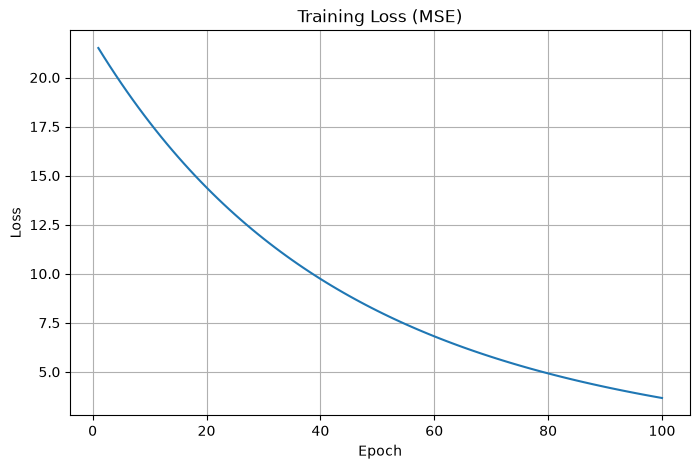

In [18]:
N = 20      # num of samples/predictions
F = 5       # num of features/weights

np.random.seed(42)
X = np.random.randn(N, F)
true_weights = np.array([2.0, -1.5, 0.8, 3.0, -0.5])
true_bias = 4.0
y = X @ true_weights + true_bias + np.random.randn(N) * 0.5  # small noise

lr = 0.01
epochs = 100

weights, bias, loss_history = train_linear_regression(X, y, lr, epochs)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.title("Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## The Problem with Unscaled Features

The toy dataset above worked fine without normalization because all features were drawn from the same distribution. In a real dataset like Ames Housing, features live on completely different scales — number of bedrooms might range from 1 to 6, while lot area ranges from 1,000 to 200,000.

This creates a problem for gradient descent. The gradient for each weight is scaled by its feature values. A weight responsible for a feature with huge values gets a huge gradient — it overshoots. A weight responsible for a small-valued feature gets a tiny gradient — it barely moves. Training becomes slow and unstable, and you have to use an extremely small learning rate just to keep the large-scale weights from diverging.

## Normalization: Z-score Standardization

The fix is to rescale every feature to the same range before training. We use z-score standardization:

$$x' = \frac{x - \mu}{\sigma}$$

Where $\mu$ is the feature mean and $\sigma$ is the standard deviation:

$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$

$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

After this transformation every feature has mean $0$ and standard deviation $1$. All weights now receive gradients on the same scale and gradient descent converges cleanly.

Note that $\sigma$ is the square root of variance. Variance uses the same squaring trick as MSE — without it, deviations like $+5$ and $-5$ would cancel to zero, giving a variance of zero even for a spread-out feature. The square root at the end brings the units back to the original scale.

**Critical rule:** compute $\mu$ and $\sigma$ from the training set only, then apply those same values to the test set. Never compute statistics from the test set — that would leak future information into training.

In [ ]:
def normalize(X_train: np.ndarray, X_test: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # axis = 0 - collapse the rows, calculate the mean for every col across N rows
    mean = np.mean(X_train, axis=0)
    variance = np.mean((X_train - mean) ** 2, axis=0)
    std = variance ** 0.5

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std      # use values learnt on train data to prevent data leakage 

    return X_train, X_test, mean, std